In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data/processed/cleaned_data.csv')
df.head()

,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,start_hour_mean,haspurchase_mean,...,purchase_latent_factor11,purchase_latent_factor12,purchase_latent_factor13,purchase_latent_factor14,purchase_latent_factor15,purchase_latent_factor16,purchase_latent_factor17,target_event,time_step,target_customer_value_lag1
0,10133.678750,2019.3250,241.65000,8.400000,16.875000,33.825000,4.225000,0.300000,15.725000,0.625000,...,0.009840,0.000000,0.502957,0.633005,0.063525,0.000000,0.000000,0,0,90.148425
1,5.359195,2019.3620,222.05173,7.827586,14.655172,31.448277,4.034483,0.258621,15.620689,0.344828,...,0.071152,0.115241,0.583373,0.395069,0.267275,0.000000,0.000000,1,0,445.168171
2,4.885714,2019.0000,297.54285,10.114285,21.000000,43.142857,2.942857,0.285714,14.171429,0.657143,...,0.000000,0.037083,1.177607,0.000000,0.000000,0.000000,0.000000,1,0,399.162689
3,4175.082759,2019.8966,106.00000,3.931035,17.655172,15.896552,3.655172,0.206897,13.620689,0.827586,...,0.000000,0.000000,0.339103,0.165644,0.000000,0.165603,0.263806,0,0,321.607950
4,3.325601,2019.3196,212.86598,7.556701,13.711340,30.989690,3.958763,0.350515,13.092784,0.628866,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.048937,0.000000,1,0,105.064542


### Define features and target:

In [3]:
X=df.drop('target_event', axis=1)
y=df['target_event']
print("Features :",X.shape)
print("Target :",y.shape)

Features : (112610, 270)
Target : (112610,)


### 1. LOW VARIANCE FEATURES

In [4]:
from sklearn.feature_selection import VarianceThreshold
selector=VarianceThreshold(threshold=0.01)
selector.fit(X)

,threshold,0.01


In [5]:
selected_columns=X.columns[selector.get_support()]
len(selected_columns)

249

In [6]:
removed_features=set(X.columns) - set(selected_columns)
len(removed_features)

21

### Remove features that contain almost no variation.
### Such features provide little predictive power.

---

### 2. Correlation with target:

In [7]:
corr_target=(
    df.corr()['target_event']
      .abs()
      .sort_values(ascending=False)
)
corr_target.head(25)

target_event                 1.000000
session_recency_min          0.534438
purchase_recency_min         0.516597
session_recency_mean         0.477474
purchase_recency_mean        0.474895
purchase_recency_max         0.367690
session_recency_max          0.352294
time_step                    0.347981
purchase_recency_sum         0.343076
session_recency_cv           0.330524
purchase_count_month_lag0    0.250551
purchase_recency_cv          0.249613
purchase_number_cv           0.242120
purchase_number_stddev       0.208986
purchase_number_max          0.208615
haspurchase_sum              0.208615
purchase_number_mean         0.208614
purchase_latent_factor2      0.205096
purchase_latent_factor13     0.196236
session_number_cv            0.189712
purchase_count_sum           0.186029
session_recency_sum          0.170000
cart_count_sum               0.167939
purchase_count_month_lag1    0.163119
session_count_month_lag0     0.158345
Name: target_event, dtype: float64

In [8]:
corr_features = corr_target.index[1:31]
corr_features

Index(['session_recency_min', 'purchase_recency_min', 'session_recency_mean',
       'purchase_recency_mean', 'purchase_recency_max', 'session_recency_max',
       'time_step', 'purchase_recency_sum', 'session_recency_cv',
       'purchase_count_month_lag0', 'purchase_recency_cv',
       'purchase_number_cv', 'purchase_number_stddev', 'purchase_number_max',
       'haspurchase_sum', 'purchase_number_mean', 'purchase_latent_factor2',
       'purchase_latent_factor13', 'session_number_cv', 'purchase_count_sum',
       'session_recency_sum', 'cart_count_sum', 'purchase_count_month_lag1',
       'session_count_month_lag0', 'customer_value_month_lag0',
       'purchase_revenue_month_lag0', 'start_hour_min', 'view_latent_factor1',
       'purchase_revenue_sum', 'purchase_count_month_ma3'],
      dtype='object')

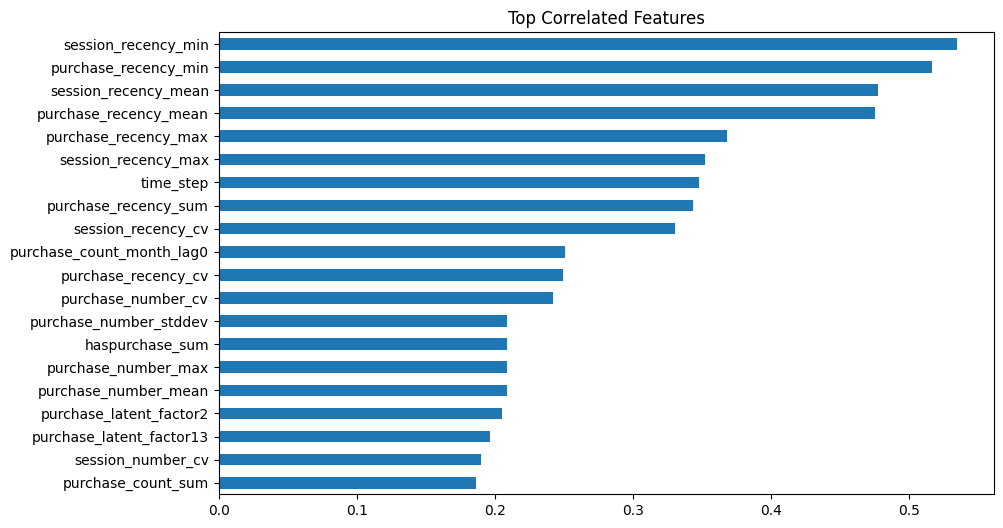

In [9]:
corr_target[1:21].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)
plt.title("Top Correlated Features")
plt.show()

---

### 3. Random Forest Importance:

In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
importance_df=pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

In [12]:
importance_df=(
    importance_df
      .sort_values(
          by='Importance',
          ascending=False
      )
)
importance_df.head(20)

,Feature,Importance
89,session_recency_min,0.054704
152,purchase_number_stddev,0.033364
204,customer_value_month_lag0,0.031777
92,purchase_recency_min,0.029093
198,purchase_count_month_ma3,0.023598
208,customer_value_month_ma3,0.022144
59,purchase_number_sum,0.022143
40,haspurchase_sum,0.021971
189,session_count_month_lag0,0.020726
121,purchase_number_max,0.020157


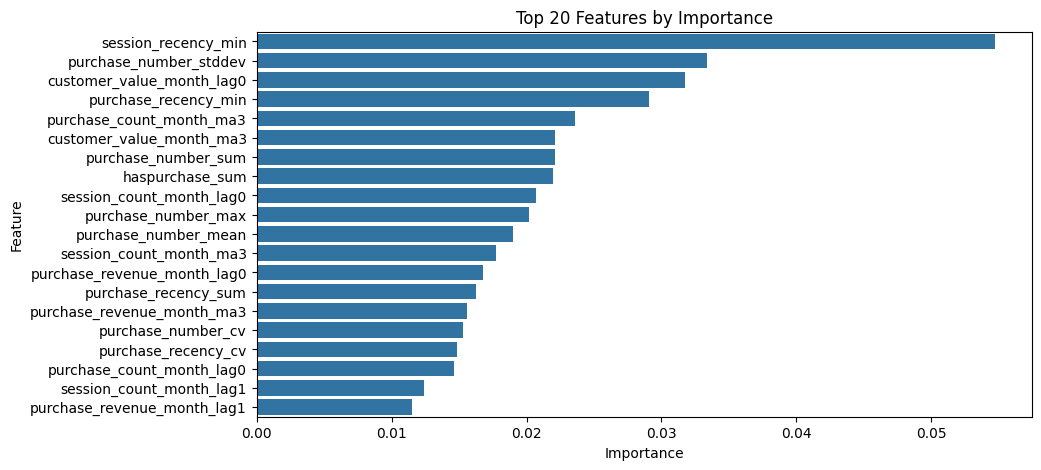

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=importance_df.head(20),
    x='Importance',
    y='Feature'
)
plt.title('Top 20 Features by Importance')
plt.show()

### Final feature list:

In [14]:
top_features=(
    importance_df
      .head(30)['Feature']
      .tolist()
)
len(top_features)

30

In [15]:
top_features

['session_recency_min',
 'purchase_number_stddev',
 'customer_value_month_lag0',
 'purchase_recency_min',
 'purchase_count_month_ma3',
 'customer_value_month_ma3',
 'purchase_number_sum',
 'haspurchase_sum',
 'session_count_month_lag0',
 'purchase_number_max',
 'purchase_number_mean',
 'session_count_month_ma3',
 'purchase_revenue_month_lag0',
 'purchase_recency_sum',
 'purchase_revenue_month_ma3',
 'purchase_number_cv',
 'purchase_recency_cv',
 'purchase_count_month_lag0',
 'session_count_month_lag1',
 'purchase_revenue_month_lag1',
 'customer_value_month_lag1',
 'session_recency_cv',
 'session_recency_mean',
 'purchase_recency_mean',
 'purchase_count_sum',
 'purchase_recency_max',
 'time_step',
 'session_recency_sum',
 'start_year_sum',
 'purchase_count_month_lag1']

### Creating reduced dataset:

In [16]:
selected_df=df[top_features + ['target_event']]

In [17]:
selected_df.shape

(112610, 31)

In [18]:
selected_df.to_csv('data/processed/selected_features.csv',index=False)

In [19]:
import pickle
with open('models/selected_features.pkl','wb') as file:
    pickle.dump(
        top_features,
        file
    )

In [20]:
print("Total Selected Features :",len(top_features))
print("\nTop Features:")
for i, feature in enumerate(top_features,1):
    print(i, feature)

Total Selected Features : 30

Top Features:
1 session_recency_min
2 purchase_number_stddev
3 customer_value_month_lag0
4 purchase_recency_min
5 purchase_count_month_ma3
6 customer_value_month_ma3
7 purchase_number_sum
8 haspurchase_sum
9 session_count_month_lag0
10 purchase_number_max
11 purchase_number_mean
12 session_count_month_ma3
13 purchase_revenue_month_lag0
14 purchase_recency_sum
15 purchase_revenue_month_ma3
16 purchase_number_cv
17 purchase_recency_cv
18 purchase_count_month_lag0
19 session_count_month_lag1
20 purchase_revenue_month_lag1
21 customer_value_month_lag1
22 session_recency_cv
23 session_recency_mean
24 purchase_recency_mean
25 purchase_count_sum
26 purchase_recency_max
27 time_step
28 session_recency_sum
29 start_year_sum
30 purchase_count_month_lag1


---
### • Started with 270 predictor variables.

### • Removed low-variance features.

### • Evaluated correlation with target variable.

### • Used Random Forest feature importance.

### • Selected top 30 most important features.

### • Saved reduced dataset for model training.